In [3]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
##Creating Quadratic Data
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers

Text(0, 0.5, 'Y dataset')

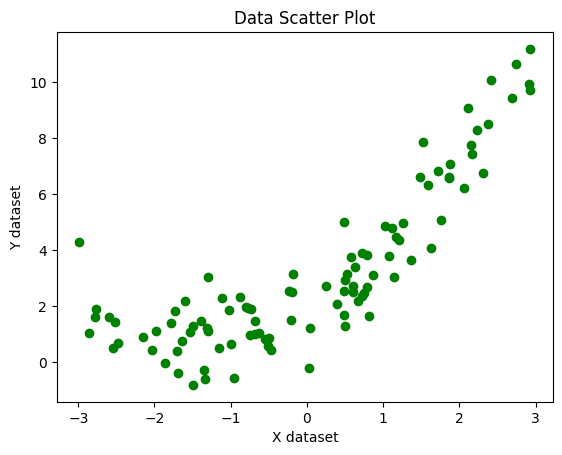

In [9]:
##Plot
plt.title("Data Scatter Plot")
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')
##Definitely not linear

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
## Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [12]:
regression_1.fit(X_train,y_train) ##This has its own intercept

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
from sklearn import metrics

In [ ]:
##Evaluation TRAIN DATA
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_train,regression_1.predict(X_train))
mae=mean_absolute_error(y_train,regression_1.predict(X_train))
rmse=np.sqrt(mse)
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",rmse) ## RMSE & MSE LOW BECAUSE THE DATA VALUES ARE NORMALISED

MSE: 2.9497244136054244
MAE: 1.4068128612984279
RMSE: 1.7174761755568617


In [ ]:
score=metrics.r2_score(y_train,regression_1.predict(X_train))
print("R2:",score)
score=metrics.r2_score(y_train,regression_1.predict(X_train))
print("Adjusted R2:",(1- (((1-score)* (X_train.shape[0]-1))/((X_train.shape[0]-1)-1-X_train.shape[1]))))
##Explaineds Variation is two low

R2: 0.6793115514245193
Adjusted R2: 0.6709819813316495


In [ ]:
##Evaluation Test DATA
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,regression_1.predict(X_test))
mae=mean_absolute_error(y_test,regression_1.predict(X_test))
rmse=np.sqrt(mse)
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",rmse) ## RMSE & MSE LOW BECAUSE THE DATA VALUES ARE NORMALISED
score1=metrics.r2_score(y_train,regression_1.predict(X_train))
print("R2:",score1)
print("Adjusted R2:",(1- (((1-score1)* (X_test.shape[0]-1))/((X_test.shape[0]-1)-1-X_test.shape[1]))))

MSE: 1.4474913874023563
MAE: 0.9114267113481113
RMSE: 1.2031173622728402
R2: 0.6793115514245193
Adjusted R2: 0.6415834986509332


Text(0, 0.5, 'Y')

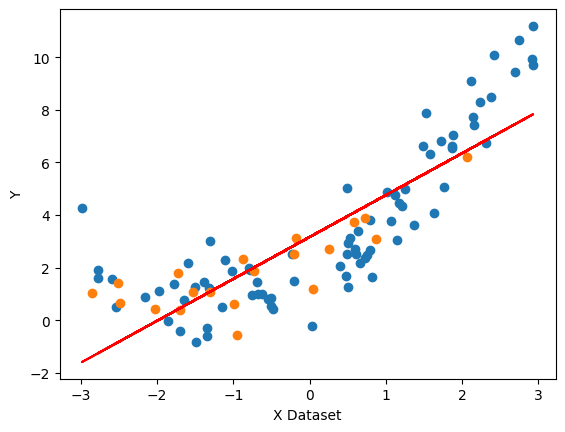

In [22]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.scatter(X_test,y_test)
plt.xlabel("X Dataset")
plt.ylabel("Y")


<h4> Polynomial Regression </h4>

In [23]:
from sklearn.preprocessing import PolynomialFeatures

In [24]:
from sklearn.pipeline import Pipeline

In [25]:
poly=PolynomialFeatures(degree=2,include_bias=True)
lr = LinearRegression()

pip_line =Pipeline([('poly', poly), ('lr',lr)])

In [26]:
pip_line.fit(X_train, y_train)

,steps,"[('poly', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [27]:
##Evaluation TRAIN DATA
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_train,pip_line.predict(X_train))
mae=mean_absolute_error(y_train,pip_line.predict(X_train))
rmse=np.sqrt(mse)
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",rmse) ## RMSE & MSE LOW BECAUSE THE DATA VALUES ARE NORMALISED

MSE: 0.9568071473581246
MAE: 0.7666162496283895
RMSE: 0.9781651943092867


In [28]:
score=metrics.r2_score(y_train,pip_line.predict(X_train))
print("R2:",score)

print("Adjusted R2:",(1- (((1-score)* (X_train.shape[0]-1))/((X_train.shape[0]-1)-1-X_train.shape[1]))))

R2: 0.8959777400705837
Adjusted R2: 0.8932758631893002


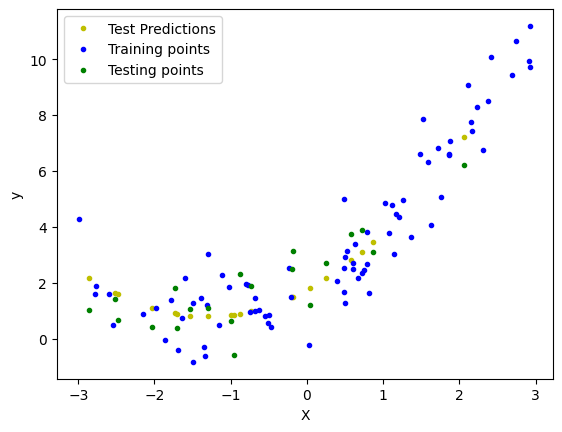

In [42]:
plt.plot(X_test, pip_line.predict(X_test), "y.", label="Test Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()